<a href="https://colab.research.google.com/github/Krrish2708/Krish-Tewatia/blob/main/EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
url = "https://raw.githubusercontent.com/salemprakash/EDA/main/Data/drug200.csv"
df = pd.read_csv(url)
df.head()

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,DrugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,DrugY


In [4]:
#Basic Statistical Analysis


In [6]:
print("Number of rows and columns:", df.shape)

Number of rows and columns: (200, 6)


In [7]:
print(df.columns)

Index(['Age', 'Sex', 'BP', 'Cholesterol', 'Na_to_K', 'Drug'], dtype='object')


In [8]:
df.dtypes

,0
Age,int64
Sex,object
BP,object
Cholesterol,object
Na_to_K,float64
Drug,object


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          200 non-null    int64  
 1   Sex          200 non-null    object 
 2   BP           200 non-null    object 
 3   Cholesterol  199 non-null    object 
 4   Na_to_K      200 non-null    float64
 5   Drug         199 non-null    object 
dtypes: float64(1), int64(1), object(4)
memory usage: 9.5+ KB


In [10]:
df.describe()

,Age,Na_to_K
count,200.000000,200.000000
mean,44.315000,16.084485
std,16.544315,7.223956
min,15.000000,6.269000
25%,31.000000,10.445500
50%,45.000000,13.936500
75%,58.000000,19.380000
max,74.000000,38.247000


In [11]:
df.describe(include='object')

,Sex,BP,Cholesterol,Drug
count,200,200,199,199
unique,2,3,3,6
top,M,HIGH,HIGH,DrugY
freq,104,77,102,89


In [12]:
# Handling Missing Data

In [13]:
df.isnull().sum()

,0
Age,0
Sex,0
BP,0
Cholesterol,1
Na_to_K,0
Drug,1


In [14]:
df[df.isnull().any(axis=1)]

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
120,28,M,NORMAL,HIGH,27.064,NaN
194,46,F,HIGH,NaN,34.686,DrugY


In [15]:
df["Cholesterol"].fillna(df["Cholesterol"].mode()[0], inplace=True)
df["Drug"].fillna(df["Drug"].mode()[0], inplace=True)

/tmp/ipykernel_2172/2081488897.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Cholesterol"].fillna(df["Cholesterol"].mode()[0], inplace=True)
/tmp/ipykernel_2172/2081488897.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, i

In [16]:
df.isnull().sum()

,0
Age,0
Sex,0
BP,0
Cholesterol,0
Na_to_K,0
Drug,0


In [17]:
#Data Cleaning

In [18]:
df.duplicated().sum()

np.int64(0)

In [19]:
#No Duplicates Present in Dataset

In [20]:
print(df.shape)

(200, 6)


In [21]:
# Data Transformation

In [22]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

In [23]:
df["Sex"] = le.fit_transform(df["Sex"])
df["BP"] = le.fit_transform(df["BP"])
df["Cholesterol"] = le.fit_transform(df["Cholesterol"])
df["Drug"] = le.fit_transform(df["Drug"])

In [24]:
df.head()

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,0,0,1,25.355,1
1,47,1,1,1,13.093,4
2,47,1,1,1,10.114,4
3,28,0,2,1,7.798,5
4,61,0,1,1,18.043,1


In [25]:
df.dtypes

,0
Age,int64
Sex,int64
BP,int64
Cholesterol,int64
Na_to_K,float64
Drug,int64


In [26]:
# Univariate Analysis

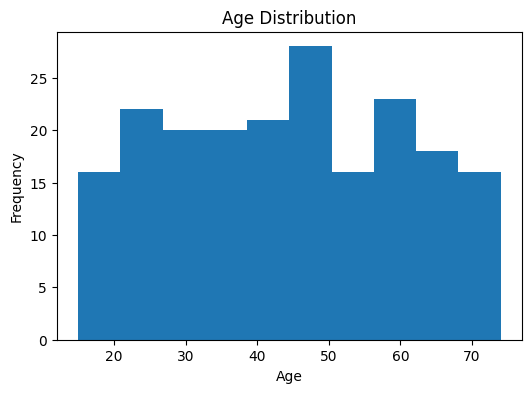

In [27]:
plt.figure(figsize=(6,4))
plt.hist(df["Age"], bins=10)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

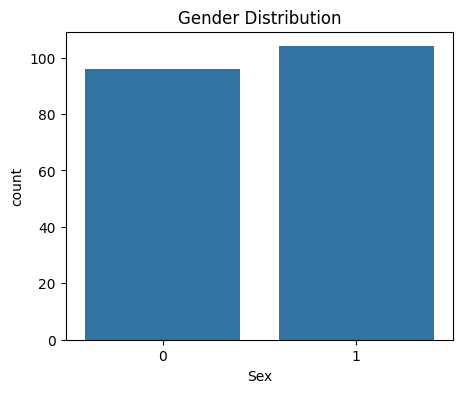

In [28]:
plt.figure(figsize=(5,4))
sns.countplot(x="Sex", data=df)
plt.title("Gender Distribution")
plt.show()

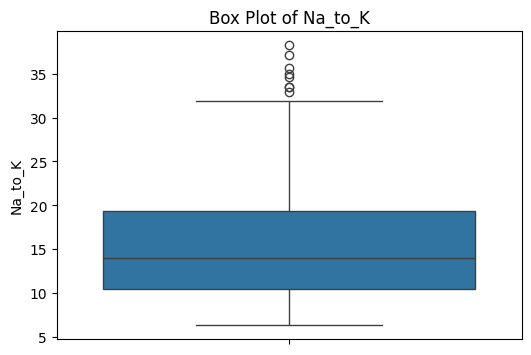

In [29]:
plt.figure(figsize=(6,4))
sns.boxplot(y=df["Na_to_K"])
plt.title("Box Plot of Na_to_K")
plt.show()

In [30]:
# Bivariate Analysis

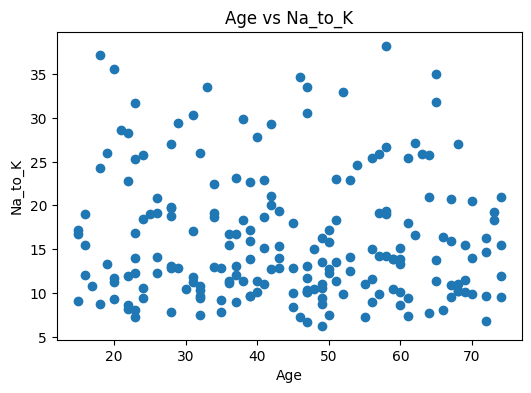

In [31]:
plt.figure(figsize=(6,4))
plt.scatter(df["Age"], df["Na_to_K"])
plt.title("Age vs Na_to_K")
plt.xlabel("Age")
plt.ylabel("Na_to_K")
plt.show()

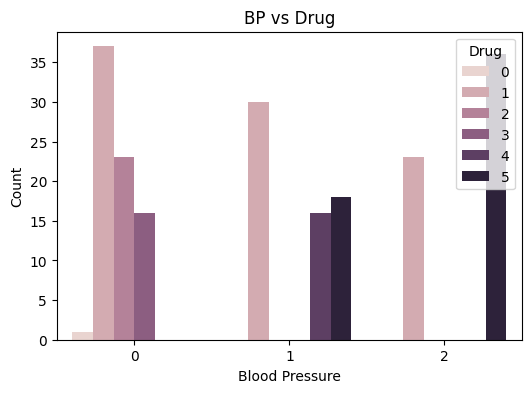

In [32]:
plt.figure(figsize=(6,4))
sns.countplot(x="BP", hue="Drug", data=df)
plt.title("BP vs Drug")
plt.xlabel("Blood Pressure")
plt.ylabel("Count")
plt.show()

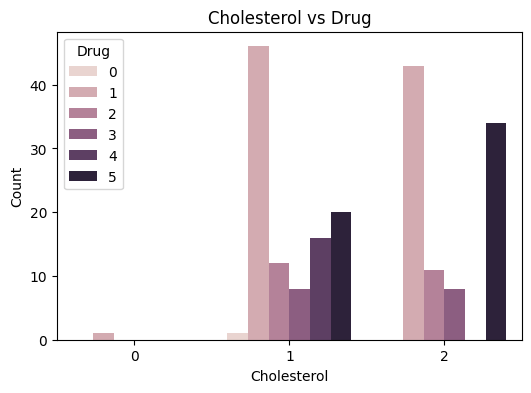

In [33]:
plt.figure(figsize=(6,4))
sns.countplot(x="Cholesterol", hue="Drug", data=df)
plt.title("Cholesterol vs Drug")
plt.xlabel("Cholesterol")
plt.ylabel("Count")
plt.show()